# 1. Importación de librerías

In [38]:
import time
from datetime import datetime     # Permite trabajar con fechas 
import pandas as pd               # Manipulacion de datos
import matplotlib.pyplot as plt   # Construcción de gráficas
import matplotlib.dates as mdates # Ejes con datos de fechas
import numpy as np                # librería numperica
import cmath                      # números complejos 
from scipy import signal          # Filtros

# librerías para estudio de series de tiempo
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.arima.model import ARIMA

# silenciar avisos de alerta
import warnings
warnings.simplefilter("ignore")

# 2. Lectura y preparación de datos

En este laboratorio emplearemos una serie de tiempo que contiene información sobre la generación de energía eléctrica en Colombia, la disponibilidad relativa de las plantas de generación y el precio de bolsa.

In [2]:
dC=pd.read_csv("data-06.csv")
dC=dC[dC.index<720].copy()
dC['Date']= pd.to_datetime(dC['Date']).copy()
dC=dC.set_index('Date')
dC.head(3)

,PPPB,ENER,ENER_H,ENER_T,DISPO,DISPO_H,DISPO_T
Date,,,,,,,
2018-01-02,146.362692,142095.0,125775.0,16320.0,0.927433,0.918636,0.952688
2018-01-03,149.231416,155941.0,139621.0,16320.0,0.929238,0.920931,0.953275
2018-01-04,151.969958,157057.0,141481.0,15576.0,0.926207,0.920451,0.945503


Exploremos la serie de tiempo de la generación de energía

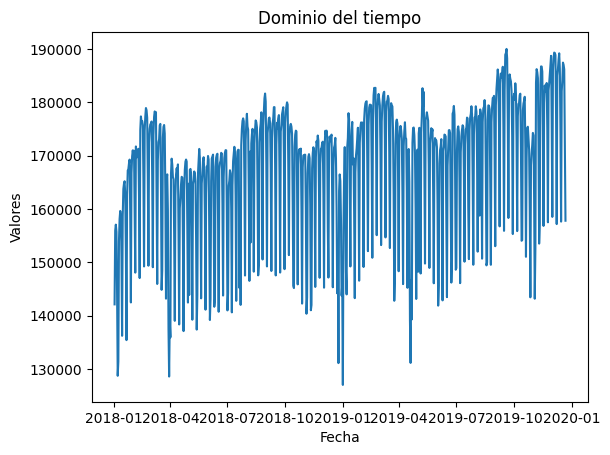

In [3]:
col='ENER'
X=np.array(dC[col])
plt.title('Dominio del tiempo')
plt.xlabel('Fecha')
plt.ylabel('Valores')
plt.plot(dC.index,X)
plt.show()


# 3. Análisis descriptivo

## 3.1. Descomposición aditiva

Podemos efectuar una descomposición de la serie en la suma de tres series que representen:
* La tendencia
* La estacionalidad
* La aleatoriedad

Para ello, debemos escoger el periodo de la ventana móvil de cálculo de la tendencia, que servira también para estimar la estacionalidad:

In [5]:
def Descomposicion(col, model, T):
    components = seasonal_decompose(dC[col], model=model,period=T)
    tendencia=components.trend
    estacionalidad = components.seasonal
    residuo =components.resid
    components.plot()
    plt.show()

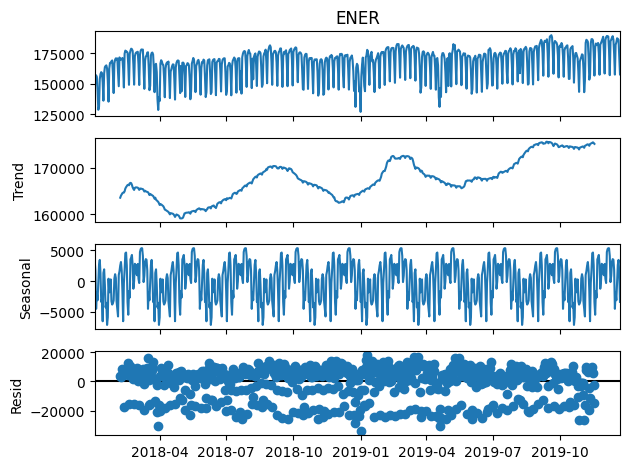

In [6]:
Descomposicion('ENER', 'Aditive', 71)

## 3.2. Descomposición multiplicativa

La descomposición puede ser multiplicativa:

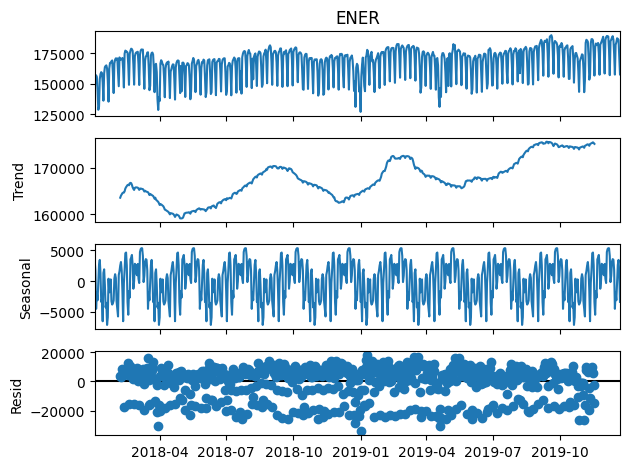

In [7]:
Descomposicion('ENER', 'Multiplicative', 71)

## 3.3. Efecto del tamaño de la ventana sobre la tendencia

Para explorar el efecto del tamaño de la ventana, graficamos la tendencia resultante para tres valores diferentes:


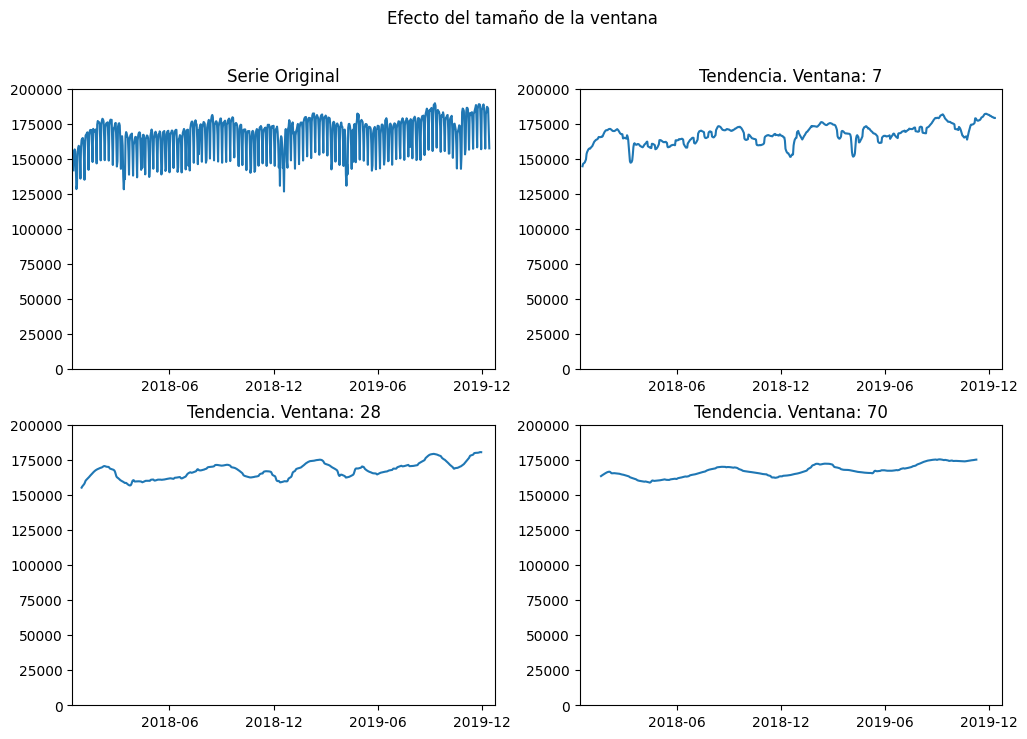

In [57]:
def graficarTendencia(ax,X,Y,subtitle, limInf, limSup):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=180))
    ax.set_xlim(pd.to_datetime('2017-12-31'), pd.to_datetime('2020-01-01'))
    ax.set_ylim(limInf,limSup)
    ax.plot(X,Y)
    ax.set_title(subtitle)

def efectoVentana(Ts, col, model, limInf, limSup):
    Tend=[]
    for T in Ts:
        components = seasonal_decompose(dC[col], model=model,period=T)
        Tend.append(components.trend)
        
    fig,axs=plt.subplots(2,2,figsize=(12,8))
    fig.suptitle("Efecto del tamaño de la ventana")
    graficarTendencia(axs[0,0],dC.index,dC[col],'Serie Original', limInf, limSup)
    graficarTendencia(axs[0,1],dC.index,Tend[0],'Tendencia. Ventana: ' + str(Ts[0]), limInf, limSup)
    graficarTendencia(axs[1,0],dC.index,Tend[1],'Tendencia. Ventana: ' + str(Ts[1]), limInf, limSup)
    graficarTendencia(axs[1,1],dC.index,Tend[2],'Tendencia. Ventana: ' + str(Ts[2]), limInf, limSup)
    plt.show()
# 
efectoVentana([7,28,70], 'ENER', 'aditive', 0, 200000)


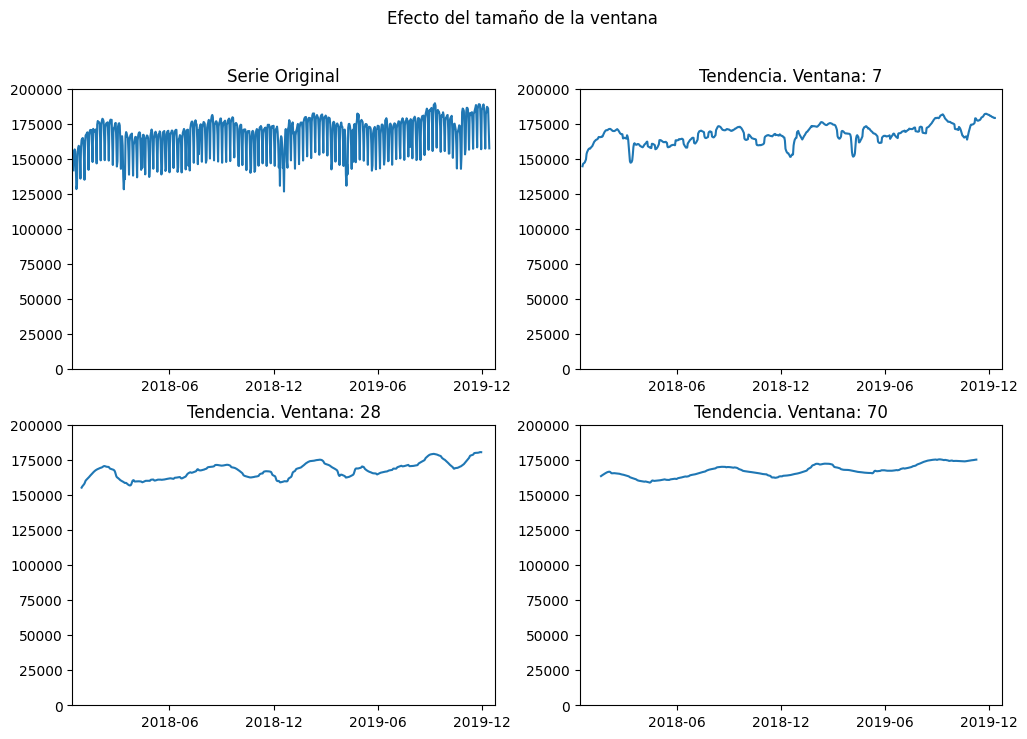

In [12]:
efectoVentana([7,28,70], 'ENER', 'multiplicative')

## 3.4. Efecto del tamaño de la ventana sobre la estacionalidad

Para explorar el efecto del tamaño de la ventana, graficamos la estacionalidad resultante para tres valores diferentes:


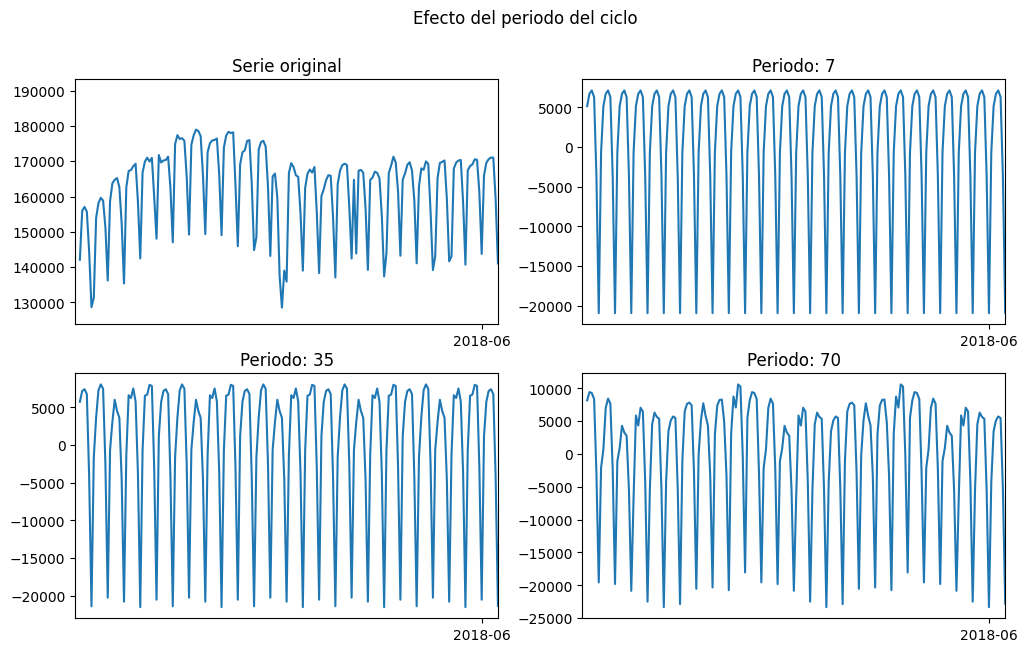

In [13]:
def graficarPeriodo(ax,X,Y,subtitle,FechaFinal):
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=180))
    ax.set_xlim(pd.to_datetime('2017-12-31'), pd.to_datetime(FechaFinal))
    ax.set_title(subtitle)
    ax.plot(X,Y)

def efectoPeriodo(Ts,FechaFinal, col, model):
    X=np.array(dC[col])
    Estacional=[]
    for T in Ts:
        components = seasonal_decompose(dC[col], model=model,period=T)
        Estacional.append(components.seasonal)
    fig,axs=plt.subplots(2,2,figsize=(12,7))
    fig.suptitle("Efecto del periodo del ciclo")
    graficarPeriodo(axs[0,0],dC.index,dC[col],'Serie original',FechaFinal)
    graficarPeriodo(axs[0,1],dC.index,Estacional[0],'Periodo: ' + str(Ts[0]),FechaFinal)
    graficarPeriodo(axs[1,0],dC.index,Estacional[1],'Periodo: ' + str(Ts[1]),FechaFinal)
    graficarPeriodo(axs[1,1],dC.index,Estacional[2],'Periodo: ' + str(Ts[2]),FechaFinal)
    plt.show()
    
efectoPeriodo([7,35,70],'2018-07-01', 'ENER', 'aditive')

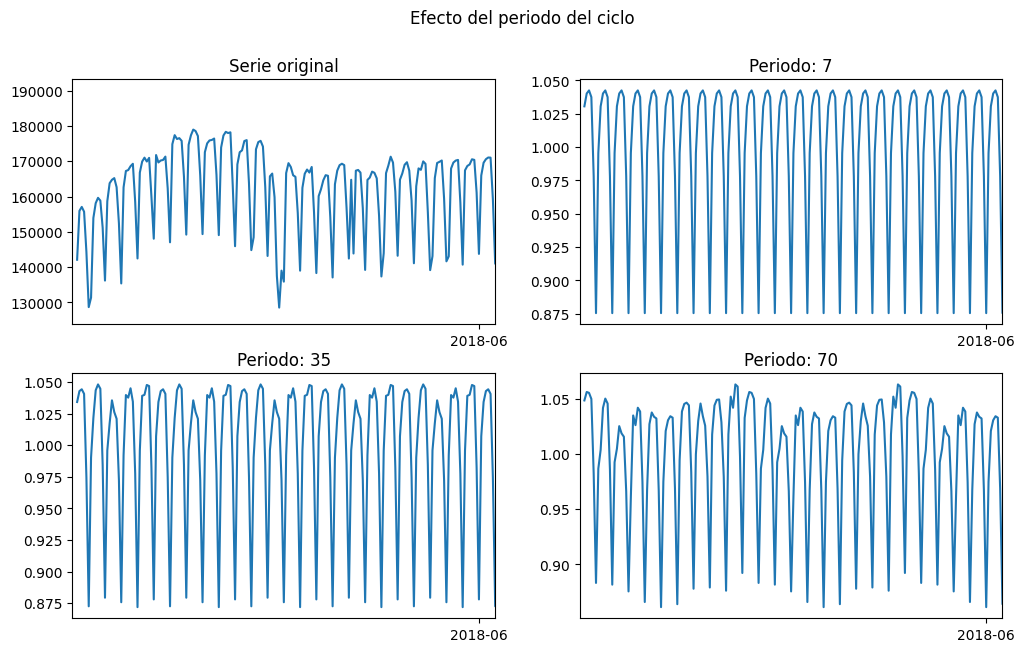

In [14]:
efectoPeriodo([7,35,70],'2018-07-01', 'ENER', 'multiplicative')

# 4. Análisis de Fourier

El análisis de Fourier permite valoar el aporte de las componentes de diferentes periodos a la serie total. La implementación disponible corresponde a la **FFT: Fast Fourier Transform**.

Exploraremos únicamente la magnitud de los componentes, en tres casos distintos:
* Con los datos originales
* Con los datos centrados en cero
* Con los datos normalizados con el escalador estándar

In [19]:
def extraerMagnitud(fft):
    fase=[]
    magn=[]
    for XX in fft:
        [X,P]=cmath.polar(XX)
        fase.append(P)
        magn.append(X)
    return magn

def graficarEspectro(ax,magn,subtitle):
    ax.plot(magn)
    ax.set_xlabel("Componente")
    ax.set_ylabel("Amplitud")
    ax.set_title("Descomposición de Fourier\n" + subtitle)

In [29]:
def NormalizarDatos(col):
    DatosNormalizados= (dC[col]-dC[col].mean())/dC[col].std()
    return DatosNormalizados

In [17]:
def AnalisisFourier(col):
    Datos            = dC[col]
    DatosCentrados   = dC[col]-dC[col].mean()
    DatosNormalizados= (dC[col]-dC[col].mean())/dC[col].std()
    ffts=[]
    ffts.append(np.fft.fft(Datos))
    ffts.append(np.fft.fft(DatosCentrados))
    ffts.append(np.fft.fft(DatosNormalizados))

    magns=[]
    for fft in ffts:
        magns.append(extraerMagnitud(fft))

    fig,axs=plt.subplots(2,2,figsize=(12,7))
    fig.suptitle("Efecto del preprocesamiento de datos")
    graficarEspectro(axs[0,0],magns[0],'Datos originales')
    graficarEspectro(axs[0,1],magns[1],'Datos centrados')
    graficarEspectro(axs[1,0],magns[2],'Datos normalizados')
    plt.tight_layout()
    plt.show()

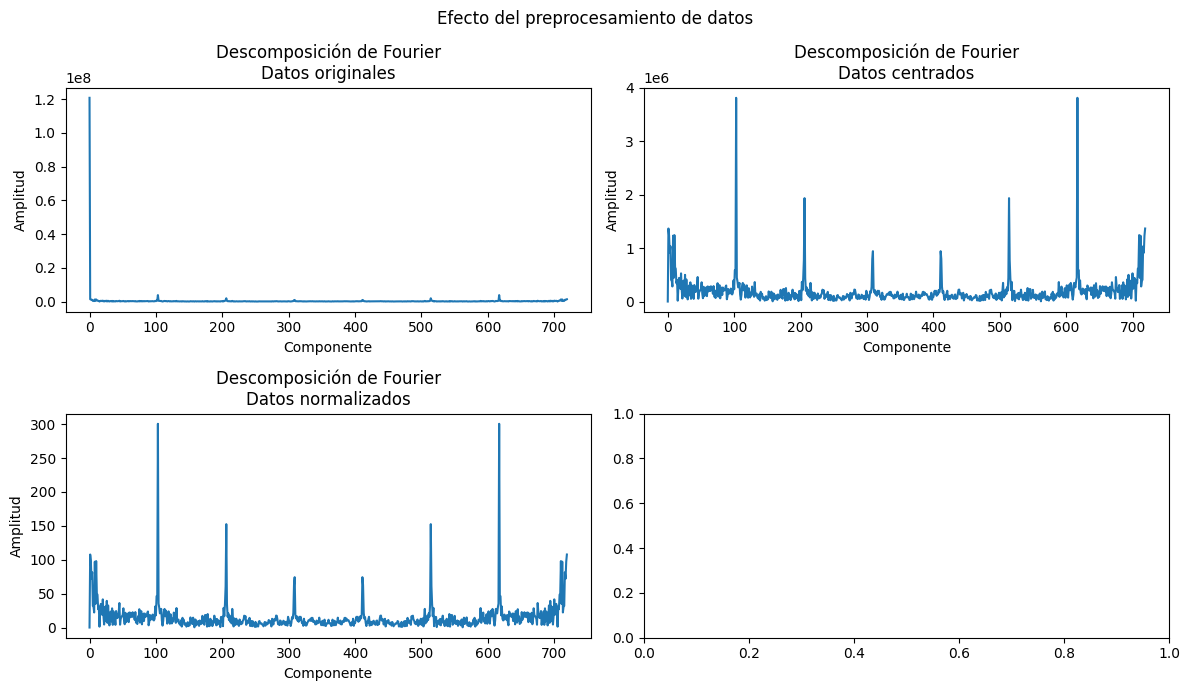

In [18]:
AnalisisFourier('ENER')

In [20]:
def AnalisisFourierNorm(col):
    DatosNormalizados= (dC[col]-dC[col].mean())/dC[col].std()
    fft=np.fft.fft(DatosNormalizados)

    magn=extraerMagnitud(fft)
    plt.plot(magn)

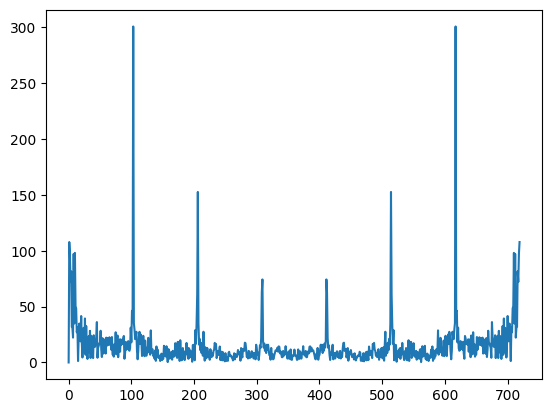

In [21]:
AnalisisFourierNorm('ENER')


## 4.1. Interpretación de resultados
Para interpretar los resultados, identificamos primero el componente más importante y luego buscamos a qué periodo corresponde:

In [22]:
def InterpretacionFourier(col):
    DatosNormalizados= (dC[col]-dC[col].mean())/dC[col].std()
    fft=np.fft.fft(DatosNormalizados)

    magn=extraerMagnitud(fft)
    print("Tamaño del arreglo de datos:")
    print(len(DatosNormalizados))
    print("Tamaño del arreglo de magnitudes:")
    print(len(magn))
    print("Posición del arreglo con valor máximo:")
    print(np.argmax(magn))
    print("Periodo (en días) correspondiente al mayor componente:")
    Tmax=len(magn)/np.argmax(magn)
    print(Tmax)

In [23]:
InterpretacionFourier('ENER')

Tamaño del arreglo de datos:
720
Tamaño del arreglo de magnitudes:
720
Posición del arreglo con valor máximo:
103
Periodo (en días) correspondiente al mayor componente:
6.990291262135922


## 4.2. Descomposición mediante filtros

Podemos extraer el aporte armónico filtrando la serie original. Acudimos a la libreria **signal** para diseñar filtros digitales. 

Diseñaremos dos filtros del tipo elíptico, de orden 5. Debemos seleccionar las frecuencias de corte. Para ello, lo que haremos será seleccionar los periodos de corte y a aprtir de esa información, encontrar las frecuencias.

* Con el primer filtro buscamos la componente de periodo 7 días. Los periodos de corte seleccionados son 6 y 8 días.
* Con el segundo filtro buscamos la componente de periodo 28 días. Los periodos de corte seleccionados son 27 y 29 días.



In [24]:
def respuestaFrecuencia(ax,a,b,subtitle):
    Fs=1
    w, h = signal.freqz(b, a, 1000, fs=Fs)
    ax.semilogx(w, 20 * np.log10(abs(h)), 'b')
    ax.set_title(subtitle)
    ax.set_xlabel('Frequency [Hz]')
    ax.set_ylabel('Amplitude [dB]')
    ax.set_ylim(-100,20)
    ax.grid(which='both', axis='both')

def filtro(Tc1,Tc2):
    Fs=1
    Orden=5
    Fc1=1/Tc2
    Fc2=1/Tc1
    print("\nPeriodos de corte:")
    print(str(Tc1)+ " - " + str(Tc2))
    print("Frecuencias de corte:")
    print(str(Fc1)+ " - " + str(Fc2))
    b, a = signal.iirfilter(Orden, [Fc1, Fc2], rs=20,rp=1, btype='band', analog=False, ftype='ellip',fs=Fs)
    return [b,a]
    
def filtrar(X,b,a):
    Y=signal.lfilter(b,a,X)
    return Y


In [25]:
def DescomposicionFiltros(col):
    X=np.array(dC[col])
    # el filtro se define por los coeficientes de los polinomios que retorna la función iirfilter
    [b1,a1]=filtro(6,8)
    [b2,a2]=filtro(27,29)

    fig,axs=plt.subplots(1,2,figsize=(12,6))
    fig.suptitle('Filtros Elíptico. Respuesta de frecuencia')
    respuestaFrecuencia(axs[0],a1,b1,'Centrado en T=7 días')
    respuestaFrecuencia(axs[1],a2,b2,'Centrado en T=28 días')
    plt.plot()


Periodos de corte:
6 - 8
Frecuencias de corte:
0.125 - 0.16666666666666666

Periodos de corte:
27 - 29
Frecuencias de corte:
0.034482758620689655 - 0.037037037037037035


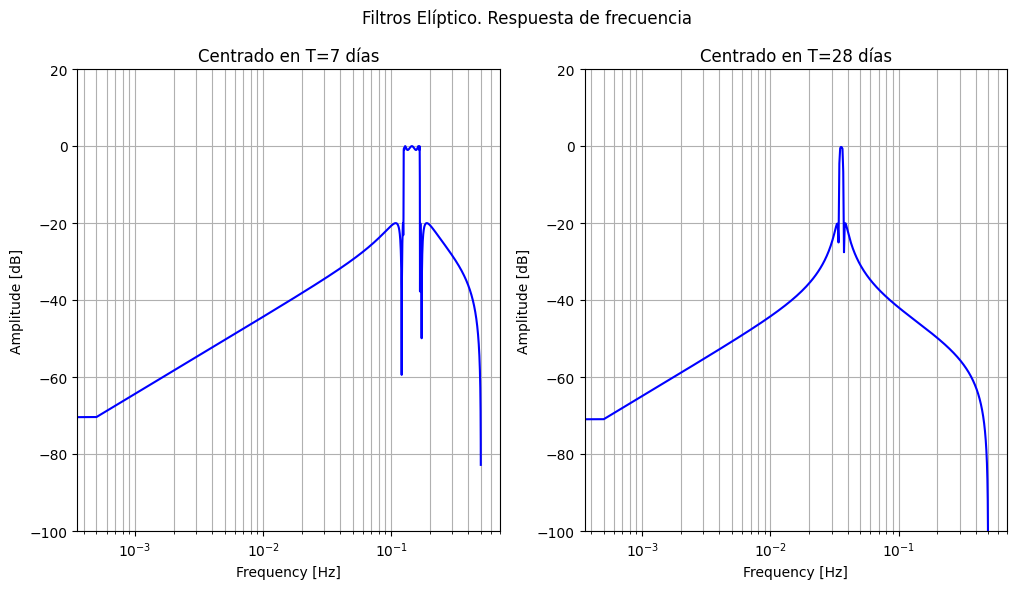

In [26]:
DescomposicionFiltros('ENER')


In [27]:
def DescomposicionFiltros2(col):
    X=np.array(dC[col])
    # el filtro se define por los coeficientes de los polinomios que retorna la función iirfilter
    [b1,a1]=filtro(6,8)
    [b2,a2]=filtro(27,29)

    YT=X.mean()*np.ones(shape=X.shape)
    Y1=filtrar(X,b1,a1)
    Y2=filtrar(X,b2,a2)

    plt.figure(figsize=(8,6))
    plt.title('Descomposición mediante filtros')
    plt.plot(X,label='Serie original')
    plt.plot(YT,label='Valor medio')
    plt.plot(Y1,label='Componente de 7 días')
    plt.plot(Y2,label='Componente de 28 días')
    plt.ylabel('Amplitud')
    plt.xlabel('Número de día')
    plt.legend()
    plt.show()


Periodos de corte:
6 - 8
Frecuencias de corte:
0.125 - 0.16666666666666666

Periodos de corte:
27 - 29
Frecuencias de corte:
0.034482758620689655 - 0.037037037037037035


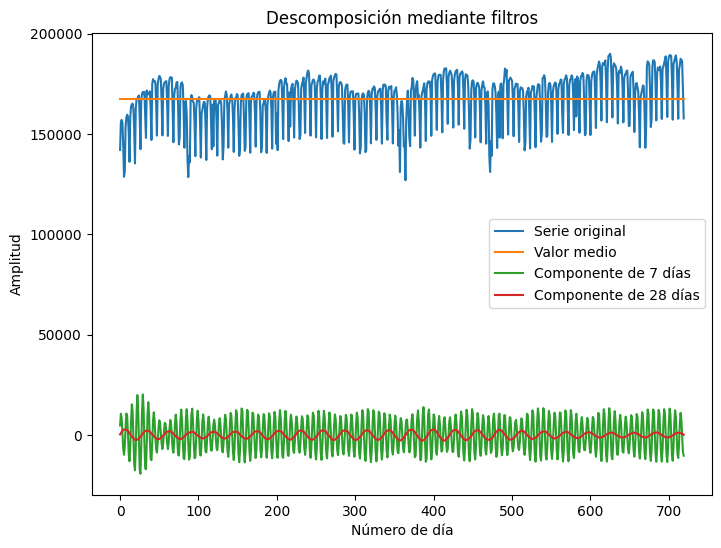

In [28]:
DescomposicionFiltros2('ENER')

# 5. Identificación de sistemas. Modelos de predicción del error

Como ejemplo de identificación de sistemas, construiremos un modelo ARIMA (*AutoRegressive Integrated Moving Average*) a partir de la serie de tiempo de la variable **ENER**. 

El modelo se define por el orden de tres polinomios. Nuestra selección ha sido $3$, $1$ y $0$.



In [34]:
def FuncARIMA(col):
    X=NormalizarDatos(col)
    model = ARIMA(X, order=(3,1,0))
    model_fit = model.fit()
    print(model_fit.summary())

In [36]:
FuncARIMA('ENER')

                               SARIMAX Results                                
Dep. Variable:                   ENER   No. Observations:                  720
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -974.680
Date:                Thu, 10 Jul 2025   AIC                           1957.359
Time:                        12:46:59   BIC                           1975.671
Sample:                    01-02-2018   HQIC                          1964.429
                         - 12-22-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1975      0.037     -5.396      0.000      -0.269      -0.126
ar.L2         -0.2907      0.047     -6.182      0.000      -0.383      -0.199
ar.L3         -0.2095      0.053     -3.963      0.0

## 5.1. Validación y actualización del modelo

Al emplear un modelo de una serie de tiempo, la información disponible aumenta con cada nuevo dato. Esta información puede usarse para actualizar *día a día* el modelo.

Una forma de validar el modelo es entrenarlo con un conjunto inicial de datos, y observar cómo se actualiza *día a día*


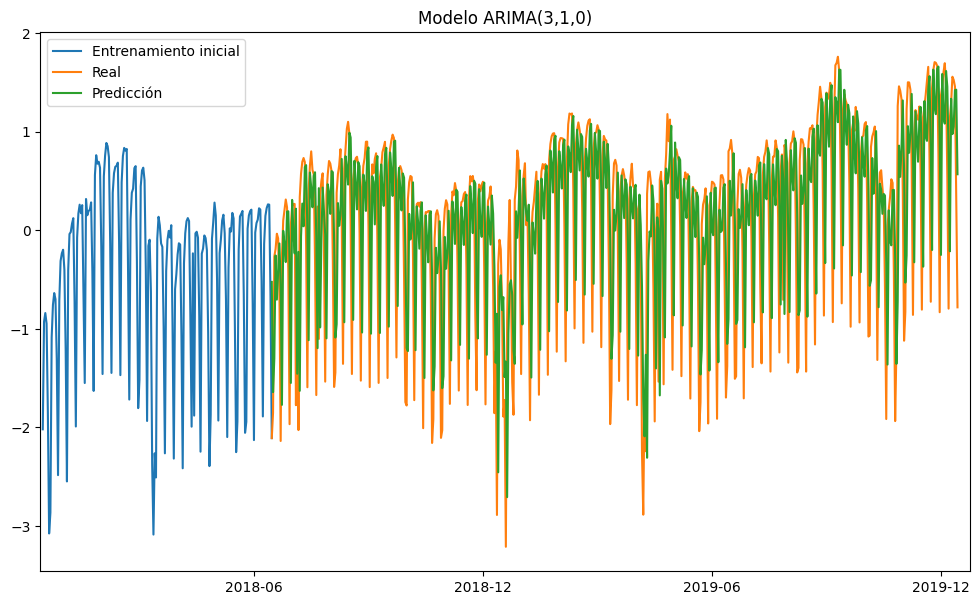

In [39]:
def modeloArima(X,n1,n2,n3,size):
    train, test = X[0:size], X[size:len(X)]
    history = [x for x in train]
    predictions = list()
    # avanzar en la validación 
    # almacenar en la historia
    for t in range(len(test)):
        model = ARIMA(history, order=(n1,n2,n3))
        model_fit = model.fit()
        output = model_fit.forecast()
        yhat = output[0]
        predictions.append(yhat)
        obs = test[t]
        history.append(obs)
    return predictions

def graficarPrediccionesArima(pred,X,size):
    train, test = X[0:size], X[size:len(X)]
    epoch_time = datetime(2018, 1, 2, 0, 0).timestamp() 
    epoch_time0 = time.mktime(datetime(1970, 1, 1, 0, 0).timetuple())
    off=(epoch_time - epoch_time0)/(24*60*60)
    off=int(off)
    tam=len(pred)+size+off
    fig,ax=plt.subplots(1,1,figsize=(12,7))
    ax.set_title('Modelo ARIMA(3,1,0)')
    ax.plot(dC.index[0:size+1],X[0:size+1],label='Entrenamiento inicial')
    ax.plot(dC.index[size:tam],test,label='Real')
    ax.plot(dC.index[size:tam],pred,label='Predicción')
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=180))
    ax.set_xlim(pd.to_datetime('2017-12-31'), pd.to_datetime('2020-01-01'))
    ax.legend()
    plt.show()

X=NormalizarDatos('ENER')
predicciones=modeloArima(X,3,1,0,180)
graficarPrediccionesArima(predicciones,X,180)


# 6. Ejercicio sugerido

Analice la serie de tiempo de la columna **DISPO**, que corresponde a la disponibilidad relativa de generación ofertada en bolsa.

Descomposición aditiva

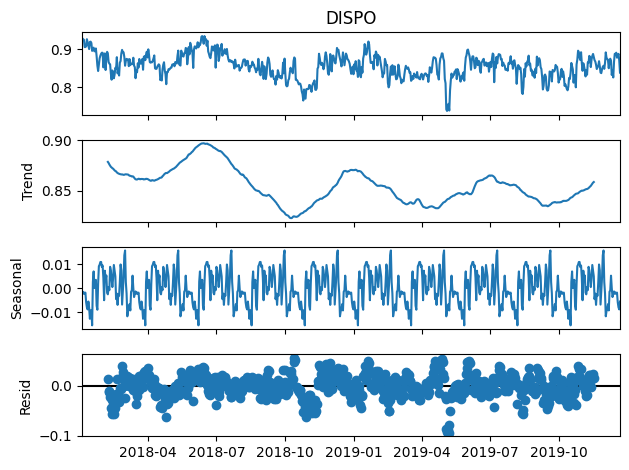

In [41]:
Descomposicion('DISPO', 'aditive', 71)

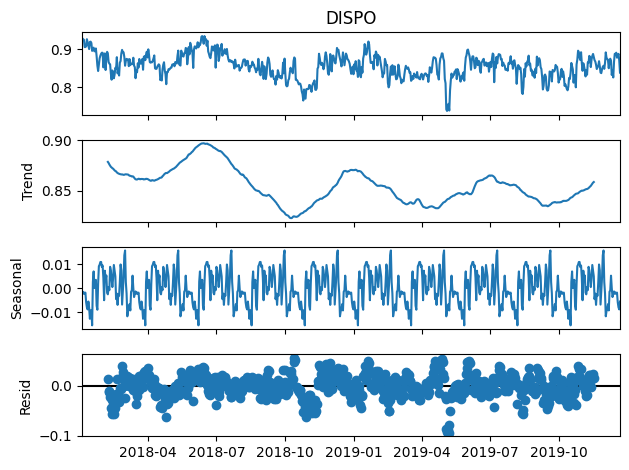

In [52]:
Descomposicion('DISPO', 'Multiplicative', 71)

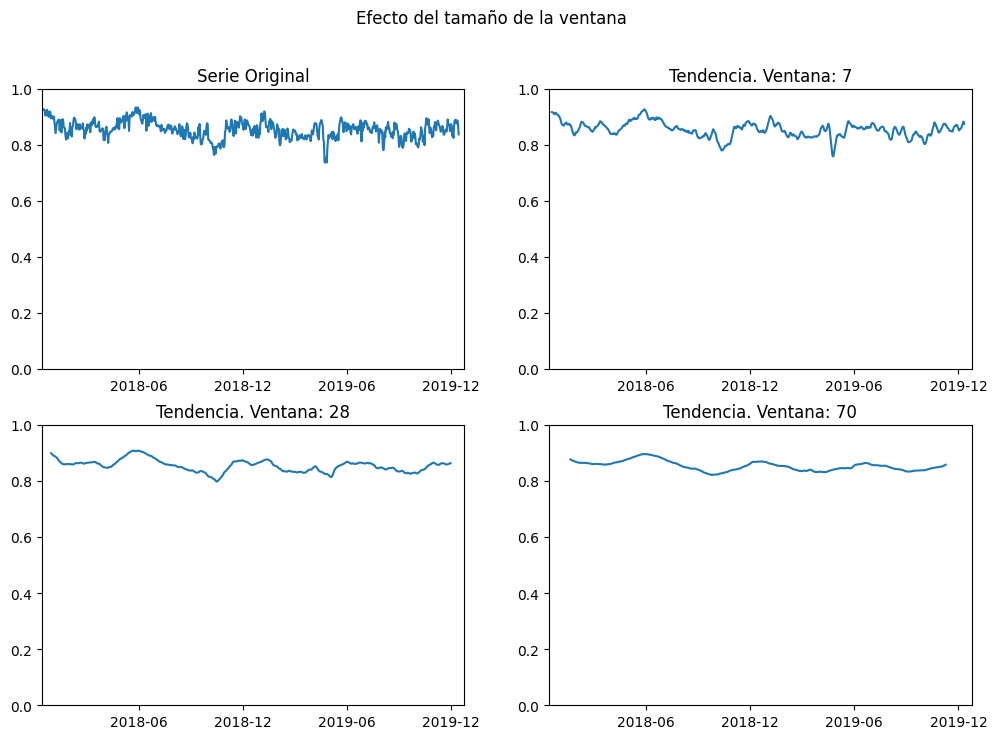

In [58]:
efectoVentana([7,28,70], 'DISPO', 'aditive', 0, 1)

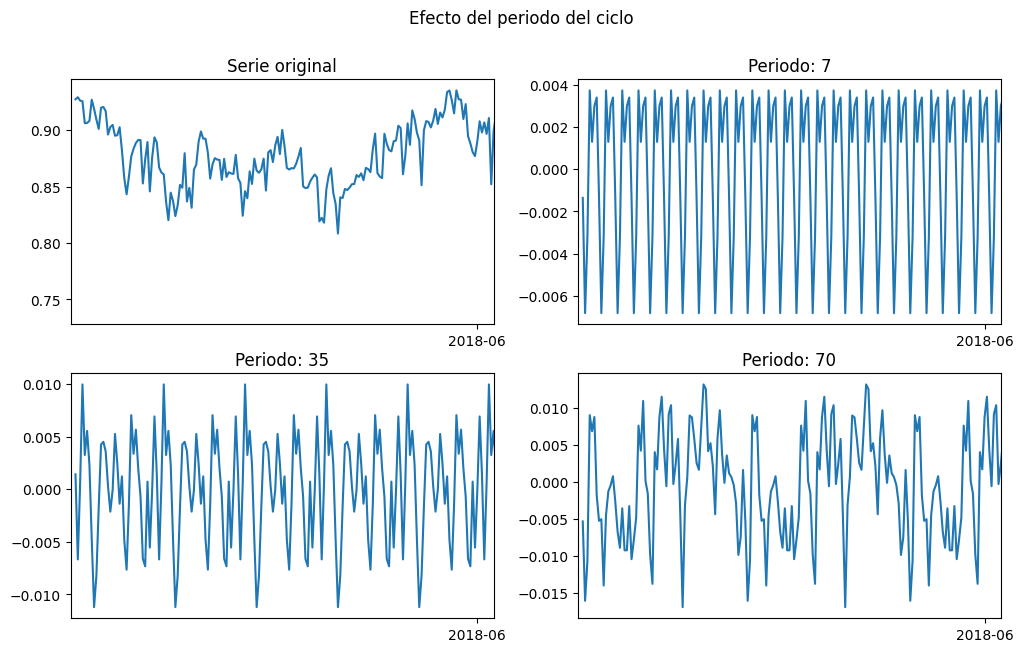

In [59]:
efectoPeriodo([7,35,70],'2018-07-01', 'DISPO', 'aditive')

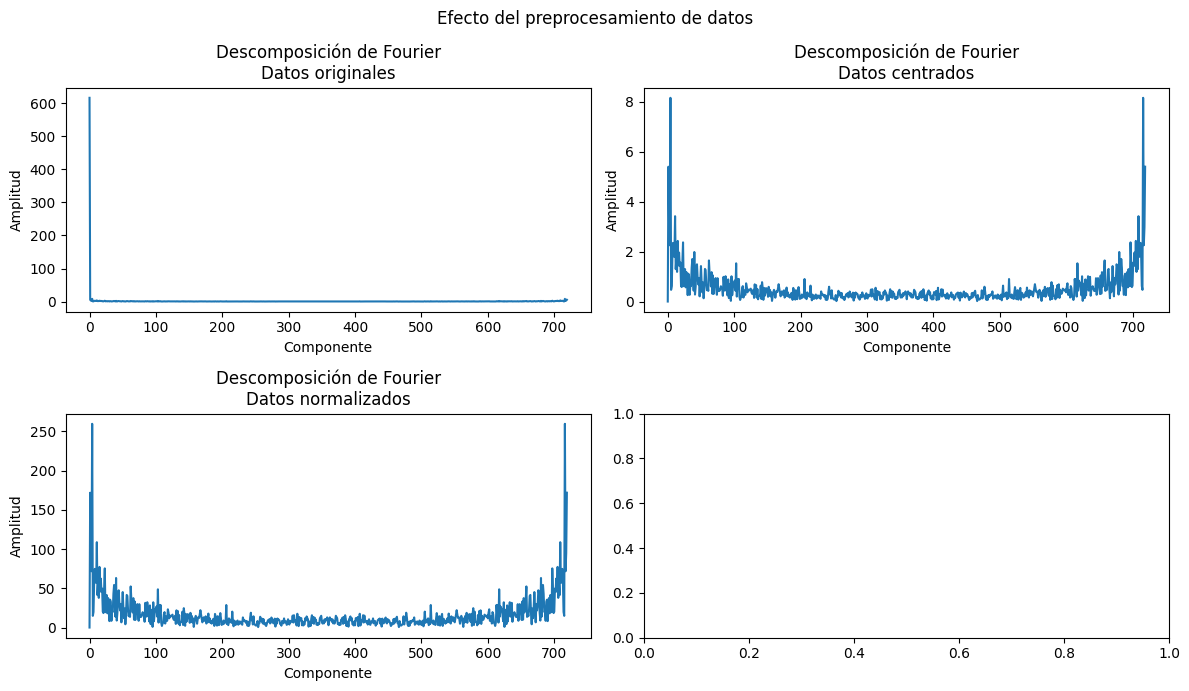

In [60]:
AnalisisFourier('DISPO')

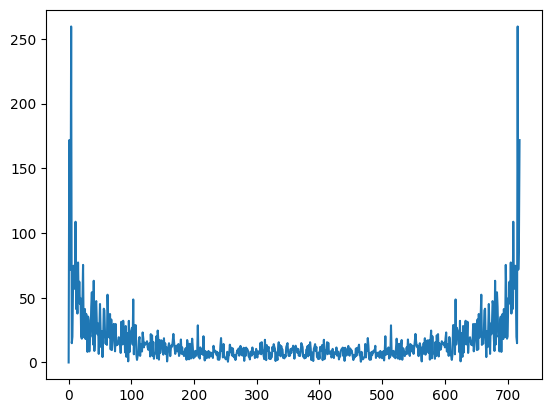

In [61]:
AnalisisFourierNorm('DISPO')

In [62]:
InterpretacionFourier('DISPO')

Tamaño del arreglo de datos:
720
Tamaño del arreglo de magnitudes:
720
Posición del arreglo con valor máximo:
4
Periodo (en días) correspondiente al mayor componente:
180.0


In [63]:
FuncARIMA('DISPO')

                               SARIMAX Results                                
Dep. Variable:                  DISPO   No. Observations:                  720
Model:                 ARIMA(3, 1, 0)   Log Likelihood                -576.636
Date:                Thu, 10 Jul 2025   AIC                           1161.272
Time:                        14:57:26   BIC                           1179.583
Sample:                    01-02-2018   HQIC                          1168.342
                         - 12-22-2019                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.1622      0.032     -5.046      0.000      -0.225      -0.099
ar.L2         -0.0754      0.034     -2.232      0.026      -0.142      -0.009
ar.L3         -0.1760      0.035     -5.050      0.0

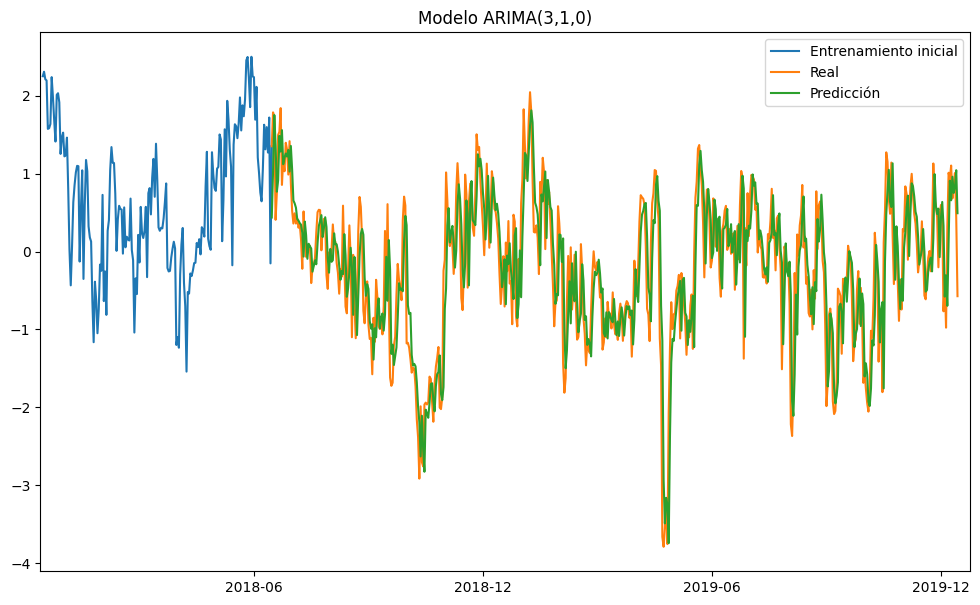

: 

In [ ]:
X=NormalizarDatos('DISPO')
predicciones=modeloArima(X,3,1,0,180)
graficarPrediccionesArima(predicciones,X,180)